In [3]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
US_Returns = pd.read_csv("Returns - Index - Major US Indices 2010-2025.csv", index_col = [0], parse_dates = True)
Sector_Returns = pd.read_csv("Returns - Index - RV - US Sectors.csv", parse_dates = True, index_col = [0])

## Helper Functions for Raw Data Processing

In [4]:
from statsmodels.tsa.stattools import adfuller

def ADF_test(time_series):

    '''
    Use adfuller(x, maxlag=None, regression='c', autolag
    ='AIC', store=False, regresults=False)

    Returns the following:
        - adf (float) – Test statistic
        - pvalue (float) – p-value    
    '''

    test_results = adfuller(time_series.dropna())
    test_statistic = test_results[0]
    p_value = test_results[1]

    #Critical Values
    Critical_Values = {}
    for threshold, adf_stat in test_results[4].items():
        Critical_Values[threshold] = adf_stat

    return test_statistic, p_value, Critical_Values['1%'], Critical_Values['5%'], Critical_Values['10%']


In [5]:
def split_into_dict(names : list,
                    df_raw_dict : dict):
    
    ''' 
    Takes many split csv files of different indicators/returns and combines it into one
    dictionary with keys for each indicator/returns.
    
    '''
    for i in names:
        try:
            df = pd.read_csv(r'Individual Datasets\{i}.csv', parse_dates=True)
        except :
            print(i)
            pass
        df.columns = ['Date', str(i)]
        df.set_index('Date', inplace=True)
        df_raw_dict[i] = df

    return df_raw_dict

In [58]:
def realign_indices(series_dict : dict, 
                   frequency : str,
                   template : str):    
    ''' 
    Realign indices from either daily/weekly to monthly => For indicator level data that we want transformed
    to monthly frequency. 

    Takes the mean

    '''
    df_template = series_dict[template]
    series_return = {}

    for i in series_dict:
        df = series_dict[i].copy()
        #If series is daily
        if series_dict[i].shape[0] > 2000:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
        #If weekly
        if series_dict[i].shape[0] < 2001 and series_dict[i].shape[0] > 800:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
            df.index = df.index.to_period(frequency).start_time
        #If monthly
        else:
            df.index = pd.to_datetime(df.index)

            if isinstance(df.index, pd.DatetimeIndex):
                pass
            else:
                df.index = df.index.to_timestamp(frequency)            
            
        df = series_dict[i].reindex(df_template.index)
        series_return[i] = df

    return series_return

In [59]:
def realign_indices_quarterly(series_dict : dict, 
                   frequency : str,
                   template : str):    
    ''' 
    Realign indices from monthly (or weekly/daily) to quarterly

    '''
    df_template = series_dict[template]
    series_return = {}

    for i in series_dict:
        df = series_dict[i].copy()
        #If series is daily
        if series_dict[i].shape[0] > 2000:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
        #If weekly
        if series_dict[i].shape[0] < 2001 and series_dict[i].shape[0] > 800:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
            df.index = df.index.to_period(frequency).start_time
        #If monthly
        else:
            df.index = pd.to_datetime(df.index)

            if isinstance(df.index, pd.DatetimeIndex):
                pass
            else:
                df.index = df.index.to_timestamp(frequency)            
            
        df = series_dict[i].reindex(df_template.index)
        series_return[i] = df

    return series_return


In [60]:
def find_ok_and_not_ok_series(rets : dict, 
                              raw_dict : dict, 
                              threshold : int = 50
                              ):
    ''' 
    Takes the raw dictionary so it can return the original series instead of the one altered
    by aligning function
    '''
    ok = {}
    not_ok = {}
    for i in rets:
        df_ = rets[i]
        if df_.iloc[:,0].isnull().sum() > threshold:
            not_ok[i] = raw_dict[i]
        else:
            ok[i] = df_

    return pd.concat(ok.values(), axis = 1), not_ok

In [7]:
def groupby_df(raw_df : pd.DataFrame,
               names : list):

    '''
    For processing raw dataframes that Refinitiv and other data sources create. Also returns dictionaries
    that contain the series that are incomplete or have null values.
    
    Takes a raw dataframe and groups it by the 'Instrument' column, which contains the names of the indicators.
    '''
    df_dict = {}
    incomplete = {}
    null_list = []
    good = {}
    

    for i in names:
        name = str(i)
        df = raw_df.groupby('Instrument').get_group(str(i)).copy()
        if df.shape[0] == 1:
            null_list.append(name)
            continue
        
        df.set_index('Date', inplace = True)
            
        df.index = pd.to_datetime(df.index).to_period('D')
        df.drop(columns = ['Instrument'], inplace = True)
        df.columns = [name]
        df_dict[name] = df

        null_count = df.isnull().sum().iloc[0]
        if null_count == 0:
            good[name] = df.iloc[:, 0]
            

        if null_count != 0:
            incomplete[name] = null_count

            if null_count < 10:
                good[name] = df.iloc[:,0]
    
    
    common_index = good[list(good.keys())[0]].index

    for i in good:
        good[i].drop_duplicates(inplace = True)
        good[i].dropna(inplace = True)
        good[i] = good[i].reindex(common_index)

    good = pd.concat(good, axis = 1)

    return good, null_list, incomplete

In [6]:
def combine_to_monthly(*series_list):
    
    cleaned = []

    for s in series_list:
        df = s.copy()
        
        # 1. Drop exact‐duplicate rows where both index and values match the previous row
        same_time = df.index.to_series().eq(df.index.to_series().shift())
        same_vals = df.eq(df.shift()).all(axis=1)
        mask = same_time & same_vals
        df = df.loc[~mask]

        # 2. Remove any remaining duplicate timestamps, keep first; sort
        df = df[~df.index.duplicated(keep="first")].sort_index()
        
        # 3. Ensure monthly frequency: infer, and if not month-end or month-start, resample
        freq = pd.infer_freq(df.index)
        if freq not in ("M", "MS", "BM", "BMS"):
            df = df.resample("ME").mean()
            df.index = df.index.to_period()
        else:
            df.index = df.index.to_period()
        cleaned.append(df)

    # 4. Inner-join on their common dates
    combined = pd.concat(cleaned, axis=1, join="outer")
    
    return combined

def add_monthly_counter(df):
    
    df = df.copy()

    # 1) Parse index to datetime (handles '2005-03-1' vs '2005-03-01' for you)
    df.index = pd.to_datetime(df.index, infer_datetime_format=True)

    # 2) Group by year‐month, and count within each group
    #    cumcount() gives 0,1,2,... so add 1 to start at 1
    df['day_counter'] = (
        df
        .groupby(df.index.to_period('M'))
        .cumcount()
        .add(1)
    )
    month_ = df.index.to_period('M').to_timestamp()
    df.index = month_ + pd.to_timedelta(df['day_counter'].sub(1), unit = 'D')

    return df.drop(columns = ['day_counter'])



## Retrieving Indices, Indicators and Price Data 

https://www.usek.edu.lb/Content/Assets/20240205WorkspaceWAinstrumentCode.pdf

### US Sector Returns and Broad-Based Indices from Eikon

In [592]:
Indices_US_Canada = ['.DJI', '.IXIC', '.INX', '.NDX', 'OEX', '.SPX', '.SPSUPX','.GSPTSE']
Indices_Sector = ['.OEX','5SP10', '.5SP25', '.5SP40', '.5SP35', '.5SP55','.5SP60', '.5SP15', '.TRCCRBTR', '.MID', '.SPCY', '.SPCDNX']

In [ ]:
#5SP10 is empty and .SPCDNX
US_Sector_Indices.to_csv('Sector Returns 2005.csv')

#Returns with some duplicates
US_Indices, null_list_, empty_count = groupby_df(data, names = Indices_US_Canada)
US_Indices = Data_US_Canada.drop_duplicates()
US_Indices = Data_US_Canada.dropna()

#Save to CSV - GSPTSE not added yet
US_Indices.to_csv('US_Indices_2005_2025.csv')

#Must add GSPTSE 
GSPTSE = data.groupby('Instrument').get_group('.GSPTSE')
GSPTSE = GSPTSE.dropna().drop_duplicates()
GSPTSE = GSPTSE.set_index('Date')
GSPTSE.index = pd.to_datetime(GSPTSE.index).to_period('D')
GSPTSE = GSPTSE.reindex(Data_US_Canada.index)
GSPTSE = GSPTSE.drop(columns = ['Instrument'])
GSPTSE.columns = ['.GSPTSE']

#Refinitiv data has duplicates 
SPX = SPX[~SPX.index.duplicated(keep='first')]
SPX 

In [ ]:
# For loop to process raw data from refinitiv
SP_500_Sector_dfs = {}
for i in SP_indices:
    name = str(i) + '_df'
    df = SP_500_2005_2025.groupby('Instrument').get_group(str(i))
    df.set_index('Date', inplace = True)
    df.index = pd.to_datetime(df.index).to_period('D')
    SP_500_Sector_dfs[name] = df
    df.to_csv(f'SP500_Sector_{name}_2005_2025.csv')

In [811]:
NASDAQ_Names = ['MSFT.O','NVDA.O','AAPL.O','AMZN.O','GOOGL.O', 'META.O', 'TSLA.O', 'AVGO.O', 'BRKb.O', 'WMT.O', 'JPM.O', 'V.O', 'LLY.O', 'MA.O', 'NFLX.O', 'XOM.O', 'ORCL.O', 'COST.O', 'HD.O', 'PG.O', 'JNJ.O', 'BAC.O', 'ABBV.O', 'KO.O', 'UNH.O', 'CRM.O', 'TMUS.O', 'PM.O', 'WFC.O', 'CVX.O']
NYSE_Names = ['BRKb.N', 'WMT.N', 'JPM.N', 'V.N', 'LLY.N', 'MA.N', 'XOM.N', 'ORCL.N', 'HD.N', 'PG.N', 'JNJ.N', 'BAC.N', 'ABBV.N', 'KO.N', 'UNH.N', 'CRM.N', 'PM.N', 'WFC.N', 'CVX.N']

In [812]:
US_returns = pd.read_csv('Returns - Index - Major US Indices 2010-2025.csv', parse_dates = True, index_col = [0])
US_returns.describe()

,.DJI,.IXIC,.INX,.NDX,.SPX,.SPSUPX,.GSPTSE,.DJI squared,.IXIC squared,.INX squared,.NDX squared,.SPX squared,.SPSUPX squared,.GSPTSE squared
count,3544.000000,3544.000000,3544.000000,3544.000000,3544.000000,3544.000000,3544.000000,3.544000e+03,3.544000e+03,3.544000e+03,3544.000000,3.544000e+03,3544.000000,3.544000e+03
mean,0.040747,0.061327,0.047766,0.069680,0.047766,0.047475,0.022482,1.152523e+00,1.731124e+00,1.241163e+00,1.797253,1.241163e+00,1.265455,8.867447e-01
std,1.072934,1.314477,1.113208,1.338994,1.113208,1.124081,0.941536,5.280398e+00,5.200895e+00,4.752189e+00,5.214927,4.752189e+00,4.849880,5.108798e+00
min,-13.841830,-13.149061,-12.765214,-13.003232,-12.765214,-12.909902,-13.176132,3.398098e-08,6.942763e-09,2.640223e-07,0.000002,2.640223e-07,0.000002,5.381217e-09
25%,-0.388619,-0.501822,-0.390888,-0.506745,-0.390888,-0.395639,-0.380765,3.812300e-02,7.182326e-02,4.140726e-02,0.076808,4.140726e-02,0.045268,3.761872e-02
50%,0.072800,0.110020,0.073795,0.117631,0.073795,0.072599,0.073294,2.194917e-01,4.150717e-01,2.546759e-01,0.432496,2.546759e-01,0.257780,1.876761e-01
75%,0.539712,0.743157,0.588320,0.758479,0.588320,0.601837,0.476680,8.948908e-01,1.585557e+00,1.047674e+00,1.646261,1.047674e+00,1.065205,6.613411e-01
max,10.764332,8.934604,8.968316,9.596637,8.968316,9.026794,11.294464,1.915963e+02,1.728978e+02,1.629507e+02,169.084045,1.629507e+02,166.665560,1.736105e+02


### Eurostoxx 60 Financial Sector Index

In [ ]:
Eurostoxx_RealEstate_Names = ['0#.SX86E']
Eurostoxx_Financial_Names = ['0#.SXFP']

Eurostoxx_R2, e = ek.get_data(Eurostoxx_RealEstate_Names,
                              fields = ['TR.Close', 'TR.ClosePrice.Date', 'TR.PriceClose', 'TR.PRICECLOSE'],
                              parameters = {'SDate': '2019-01-01',
                                    'EDate': '2025-05-27',
                                    'Frq':'D'})

Eurostoxx_Fin2, e = ek.get_data(Eurostoxx_Financial_Names,
                              fields = ['TR.Close', 'TR.ClosePrice.Date', 'TR.PriceClose', 'TR.PRICECLOSE'],
                              parameters = {'SDate': '2019-01-01',
                                    'EDate': '2025-05-27',
                                    'Frq':'D'})

Eurostoxx_RE_df, RE_null, RE_empty = groupby_df(Eurostoxx_R2, names = Eurostoxx_R2['Instrument'].unique().tolist())
Eurostoxx_Fin_df, Fin_null, FE_empty = groupby_df(Eurostoxx_Fin2, names = Eurostoxx_Fin2['Instrument'].unique().tolist())

### Processing Index Constitutents Data

In [14]:
Eurostoxx_Fin_Rawdf = pd.read_csv('Eurostoxx_Financial_Index_Members.csv')
Eurostoxx_RE_Rawdf = pd.read_csv('Real_Estate_Index.csv')
SP_Industrial_Rawdf = pd.read_csv('Industrial_Rets.csv')
NASDAQ_100_Rawdf = pd.read_csv('NASDAQ100_prices_index.csv')


C:\Users\Phillip\AppData\Local\Temp\ipykernel_27220\3588801005.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  SP_Industrial_Rawdf = pd.read_csv('Industrial_Rets.csv')
C:\Users\Phillip\AppData\Local\Temp\ipykernel_27220\3588801005.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  NASDAQ_100_Rawdf = pd.read_csv('NASDAQ100_prices_index.csv')


In [418]:
# Formatting Eurostoxx Financials
Eurostoxx_Fin_Rawdf2 = Eurostoxx_Fin_Rawdf.drop(
    columns = ['fic', 'isin', 'gvkey', 'prchd', 'prcld', 'cshtrd']).set_index(
        ['datadate', 'conm']).unstack(1).copy()

Eurostoxx_Fin_Rawdf2.index = pd.to_datetime(Eurostoxx_Fin_Rawdf2.index)
Eurostoxx_Fin_Rawdf3 = Eurostoxx_Fin_Rawdf2.loc['2019':].dropna(axis = 1).copy()
Eurostoxx_Fin_Rawdf3.index.name = 'Date'
Eurostoxx_Fin_Rawdf4 = Eurostoxx_Fin_Rawdf3['prccd'].copy()
Eurostoxx_Fin_Rawdf4 = (np.log(Eurostoxx_Fin_Rawdf4 / Eurostoxx_Fin_Rawdf4.shift()) * 100).dropna()
Eurostoxx_Fin_Rawdf4.columns.name = None
Eurostoxx_Fin_Rawdf4.to_csv('Eurostoxx_Financial_Sector_Prices.csv')


In [417]:
# Formatting Real Estate Financials
Eurostoxx_RE_Rawdf2 = Eurostoxx_RE_Rawdf.drop(
    columns = ['fic', 'isin', 'gvkey', 'prchd', 'prcld', 'cshtrd']).set_index(
        ['datadate', 'conm']).unstack(1).copy()

Eurostoxx_RE_Rawdf2.index = pd.to_datetime(Eurostoxx_RE_Rawdf2.index)
Eurostoxx_RE_Rawdf3 = Eurostoxx_RE_Rawdf2.loc['2019':].dropna(axis = 1).copy()
Eurostoxx_RE_Rawdf3.index.name = 'Date'
Eurostoxx_RE_Rawdf4 = Eurostoxx_RE_Rawdf3['prccd'].copy()
Eurostoxx_RE_Rawdf4 = (np.log(Eurostoxx_RE_Rawdf4 / Eurostoxx_RE_Rawdf4.shift()) * 100).dropna()
Eurostoxx_RE_Rawdf4.columns.name = None
Eurostoxx_RE_Rawdf4.to_csv('Eurostoxx_RealEstate_Sector_Prices.csv')

In [ ]:
SP_Industrial_Rawdf2 = SP_Industrial_Rawdf.drop(
    columns = ['gvkey', 'iid', 'prchd', 'prcld', 'prcod']).set_index(['datadate', 'tic']).unstack(1).copy()

SP_Industrial_Rawdf2.index = pd.to_datetime(SP_Industrial_Rawdf2.index)
SP_Industrial_Rawdf3 = SP_Industrial_Rawdf2['prccd'].copy()
SP_Industrial_Rawdf4 = SP_Industrial_Rawdf3.drop(['DAY.','BA.PA', 'ARNC.PB', 'HON.WI', 'DOV.WI', 'SWU', 'HUB.A', 'SWP.2', 'SWH', 'FTV.PA', 'SWT'], axis = 1)
SP_Industrial_Rawdf5 = SP_Industrial_Rawdf4.ffill(limit = 1)
SP_Industrial_Rawdf5 = (np.log(SP_Industrial_Rawdf5 / SP_Industrial_Rawdf5.shift()) * 100).dropna()
SP_Industrial_Rawdf5.index.name = 'Date'
SP_Industrial_Rawdf5.columns.name = None
SP_Industrial_Rawdf5.loc['2019':].to_csv('SP500_Industrials_Index_Returns.csv')

In [ ]:
# To filter out inactive NASDAQ members
NASDAQ_Tickers, e = ek.get_data(['0#.NDX'], fields = ['TR.ExchangeTicker'], parameters = {'SDate':'2025-01-01',
                                                                             'EDate': '2025-05-01'})

NASDAQ_Tickers = NASDAQ_Tickers['Exchange Ticker'].to_list()

NASDAQ_Active = []

for i in NASDAQ_Tickers:
    if i in NASDAQ_100_Rawdf4.columns:
        NASDAQ_Active.append(i)

In [92]:
NASDAQ_100_Rawdf2 = NASDAQ_100_Rawdf.drop(
    columns = ['gvkey', 'iid', 'prchd', 'prcld', 'prcod']).set_index(['datadate', 'tic']).unstack(1).copy()

NASDAQ_100_Rawdf2.index = pd.to_datetime(NASDAQ_100_Rawdf2.index)
NASDAQ_100_Rawdf3 = NASDAQ_100_Rawdf2['prccd'].copy()
NASDAQ_100_Rawdf3.index.name = 'Date'
NASDAQ_100_Rawdf4 = NASDAQ_100_Rawdf3.loc['2019':].copy().ffill(limit = 1).dropna(axis = 1)
NASDAQ_100_Rawdf4.columns.name = None
# GOOGL has 2 tickers, GOOG and GOOGL
NASDAQ_100_Rawdf5 = NASDAQ_100_Rawdf4[NASDAQ_Active].copy().drop(columns = ['GOOGL'])
NASDAQ_100_Rawdf5 = np.log( NASDAQ_100_Rawdf5 / NASDAQ_100_Rawdf5.shift()).dropna() * 100
NASDAQ_100_Rawdf5.to_csv('NASDAQ Index Returns.csv')

In [73]:
# Getting indice returns

index_list = ['.NDX', '.SPLRCI', '.SX86E', '.SXFE']

Eurostoxx_RE_Index_Price, e = ek.get_data('.SXFE', 
                               fields = ['TR.ClosePrice', 'TR.ClosePrice.Date'],
                               parameters = {'SDate': '2018-01-01',
                                             'EDate': '2025-05-20',
                                             'Frq': 'D'})

c:\Users\Phillip\AppData\Local\Programs\Python\Python39\lib\site-packages\eikon\data_grid.py:255: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [87]:
Eurostoxx_Financial_Index_Price2 = Eurostoxx_Financial_Index_Price.set_index('Date').drop(columns = ['Instrument'])
Eurostoxx_Financial_Index_Price2.index = pd.to_datetime(Eurostoxx_Financial_Index_Price2.index).strftime('%Y-%m-%d')
Eurostoxx_Financial_Index_Price2.columns.name = 'Eurostoxx Financial Index'
Eurostoxx_Financial_Index_Price2.to_csv('Eurostoxx_Financial_Index.csv')

In [85]:
Eurostoxx_RE_Index_Price2 = Eurostoxx_RE_Index_Price.set_index('Date').drop(columns = ['Instrument']).copy()
Eurostoxx_RE_Index_Price2.index = pd.to_datetime(Eurostoxx_RE_Index_Price2.index).strftime('%Y-%m-%d')
Eurostoxx_RE_Index_Price2.columns.name = 'Eurostoxx Real Estate Index'
Eurostoxx_RE_Index_Price2.to_csv('Eurostoxx_Real_Estate_Index.csv')

## Indicators and Economic Variables

Data below is retrieved from mainly Refinitiv. Some will be fed in as MIDAS variables as levels, some as first differences, some as log differences and quarterly annualised growth rates. An augmented Dickey Fuller test is applied to every indicator to ensure stationarity conditions.

## Processing and Compiling Indicator Data 

##### Pulling Data from FRED

In [560]:
Indicator_List_FRED = {
                'US EPU': 'USEPUINDXM',
                'China EPU': 'CHNMAINLANDEPU',
                'EU EPU': 'EUEPUINDXM',
                'Industrial Production (Manufacturing Only)': 'IPMAN',
                'Global Price of Industrial Materials': 'PINDUINDEXM',
                'Electricity Price CPI in US Cities': 'CUSR0000SEHF01',
                'Number of Car Sales': 'TOTALSA',
                'T10-2 yield curve (US)': 'T10Y2Y',
                'T10-3 yield curve (US)': 'T10Y3M',
                'Default Spread (BofA High Yield OAS)': 'BAMLH0A0HYM2',
                'Defaut Spread (BofA EU High Yield)': 'BAMLHE00EHYIOAS',
                    }

In [562]:
for key, value in Indicator_List_FRED.items():
    df = fred.get_series(value, observation_start = '2005-01-01')   
    df = pd.DataFrame(df)
    df.index = df.index.strftime('%Y-%m')
    df.columns = [key]
    df.to_csv(f'Individual Datasets\{key}.csv')

##### Citi Surprise Index

In [193]:
CitiSurpriseNames = ['.CESIEUR', '.CESICNY', '.CESIGL', '.CESIUSD', '.CESIG10']

CitiSurprise_raw_df, e = ek.get_data(['.CESIEUR', '.CESICNY', '.CESIGL', '.CESIUSD', '.CESIG10'],
                                     fields = ['TR.ClosePrice', 'TR.ClosePrice.Date'],
                                     parameters = {'SDate': '2005-01-01',
                                             'EDate': '2025-05-15',
                                             'Frq' : 'M'})

CitiSurprise_df = CitiSurprise_raw_df.copy()
CitiSurprise_df = CitiSurprise_df.reset_index().pivot(
    index = 'Date',
    columns = 'Instrument',
    values = 'Close Price'
)

CitiSurprise_df.index = pd.to_datetime(CitiSurprise_df.index).strftime('%Y-%m')
CitiSurprise_df.to_csv('Citi Surprise Indicators.csv')

Results = CitiSurprise_df.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

c:\Users\Phillip\AppData\Local\Programs\Python\Python39\lib\site-packages\eikon\data_grid.py:255: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,T-stat,p-value,1%,5%,10%
Instrument,,,,,
.CESICNY,-2.84,0.05,-3.46,-2.87,-2.57
.CESIEUR,-4.03,0.00,-3.46,-2.87,-2.57
.CESIG10,-4.08,0.00,-3.46,-2.87,-2.57
.CESIGL,-4.12,0.00,-3.46,-2.87,-2.57
.CESIUSD,-4.23,0.00,-3.46,-2.87,-2.57


##### Yield Curve + Spreads

In [246]:
Euro_Yields = ['DE10YT=RR', 'DE2YT=RR', 'DE3MT=RR']

Euro_Yields_df, e = ek.get_data(Euro_Yields,
                                fields = ['TR.MidYield', 'TR.MidYield.Date'],
                                parameters = {'SDate': '2017-01-01',
                                             'EDate': '2025-05-15',
                                             'Frq' : 'D'})


c:\Users\Phillip\AppData\Local\Programs\Python\Python39\lib\site-packages\eikon\data_grid.py:255: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [ ]:
Euro_Yields_df1 = Euro_Yields_df.copy().drop_duplicates()
Euro_Yields_df1 = Euro_Yields_df1.reset_index().pivot(
    index = 'Date',
    columns = 'Instrument',
    values = 'Mid Yield'
)

Euro_Yields_df1.index = pd.to_datetime(Euro_Yields_df1.index)

Euro_Yields_df2 = Euro_Yields_df1.resample('ME').mean().copy()
Euro_Yields_df2.index = pd.to_datetime(Euro_Yields_df2.index).strftime('%Y-%m')
Euro_Yields_df2.rename(columns = {'DE10YT=RR': '10Y', 'DE2YT=RR': '2Y', 'DE3MT=RR': '3M'}, inplace = True)
Euro_Yields_df2.to_csv('Euro Yield Curve Data.csv')

Euro_10Y2Y = Euro_Yields_df2['10Y'] - Euro_Yields_df2['2Y']
Euro_10Y3M = Euro_Yields_df2['10Y'] - Euro_Yields_df2['3M']

Euro_Spreads = pd.concat([Euro_10Y2Y, Euro_10Y3M], axis = 1)
Euro_Spreads.columns = ['10Y2Y', '10Y3M']
Euro_Spreads.to_csv('Euro Spreads.csv')

# Must Difference 
Euro_Spreads = pd.concat([Euro_10Y2Y, Euro_10Y3M], axis = 1)
Euro_Spreads.columns = ['10Y2Y', '10Y3M']
Euro_Spreads.to_csv('Euro Spreads.csv')

# Check Stationarity
Results = Euro_Spreads.diff().apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
10Y2Y,-7.67,0.0,-3.5,-2.89,-2.58
10Y3M,-7.50,0.0,-3.5,-2.89,-2.58


##### Supply Chain + Industrial Indicators

In [66]:
GSCIP = pd.read_csv('.Global Supply Chain Index.csv', header = 0, index_col = [0], parse_dates = True)
GSCIP = GSCIP.iloc[:, 0]
GSCIP.index.name = 'Date'
GSCIP = pd.DataFrame(GSCIP)
GSCIP.columns = ['Global Supply Chain Pressure Index']

# Is stationary no need to transform it
Results = GSCIP.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
GSCIP.loc['2005-01-01':].to_csv('Global Supply Chain Index.csv')
Results.T

,T-stat,p-value,1%,5%,10%
Global Supply Chain Pressure Index,-3.28,0.02,-3.46,-2.87,-2.57


##### Compiling Monthly Data

In [ ]:
# Volatility
skew = pd.read_csv(r'Individual Datasets\SkewX_2005_2025.csv', parse_dates = True, index_col = [0])
equity_vol_measure = pd.read_csv(r'Individual Datasets\Equity Vol Measure.csv', index_col = [0], parse_dates = True)
vix = pd.read_csv(r'Individual Datasets\VIX (good version).csv', parse_dates = True, index_col = [0]) 
MOVE = pd.read_csv(r'Individual Datasets\MOVE_2005_2025.csv', parse_dates = True, index_col=[0])
oil_vol = pd.read_csv(r'Individual Datasets\OVX_2007_2025.csv', parse_dates = True, index_col=[0])
VVIX = pd.read_csv(r'Individual Datasets\VVIX (good version).csv', parse_dates = True, index_col = [0])

# Sentiment
NFCI_Agg = pd.read_csv(r'Individual Datasets\NFCI.csv', parse_dates=True, index_col = [0])
UMich = pd.read_csv(r'Individual Datasets\UMich Sentiment.csv', parse_dates = True, index_col = [0]) 
BKK_NFCI_StLouis = pd.read_csv(r'Individual Datasets\BKK_NFCI_StLouis.csv', index_col = [0], parse_dates = True)
China_EPU = pd.read_csv(r'Individual Datasets\China EPU.csv', index_col = [0], parse_dates = True)
US_EPU = pd.read_csv(r'Individual Datasets\US EPU.csv', index_col = [0], parse_dates = True)
GPR_China_US_Saudi_Ger_Global = pd.read_csv(r'Individual Datasets\GPR (Differenced).csv', parse_dates = True, index_col = [0])
ESG = pd.read_csv(r'Individual Datasets\ESG.csv', index_col = [0], parse_dates = True)
Citi = pd.read_csv(r'Individual Datasets\Citi Surprise Indicators.csv', parse_dates = True, index_col = [0])

# Economic
Housing_Starts = pd.read_csv(r'Individual Datasets\Housing Start.csv', parse_dates = True, index_col=[0])
Unemployment_Rate = pd.read_csv(r'Individual Datasets\Unemployment Rate.csv', parse_dates = True, index_col=[0])
Inflation = pd.read_csv(r'Individual Datasets\Core Inflation.csv', parse_dates = True, index_col=[0])
CarSales = pd.read_csv(r'Individual Datasets\Number of Car Sales.csv', index_col = [0], parse_dates = True)
Electricity_Price = pd.read_csv(r'Individual Datasets\Electricity Price CPI in US Cities.csv', index_col = [0], parse_dates = True)

# Industrial
GSCIP = pd.read_csv(r'Individual Datasets\GSCIP.csv', index_col =[0], parse_dates = True)
IndPro = pd.read_csv(r'Individual Datasets\IndPro.csv', index_col =[0], parse_dates = True)
New_Orders = pd.read_csv(r'Individual Datasets\New Orders.csv', parse_dates = True, index_col=[0])
PPI = pd.read_csv(r'Individual Datasets\PPI.csv', parse_dates = True, index_col=[0])
IndPro_Manufacturing = pd.read_csv(r'Individual Datasets\Industrial Production (Manufacturing Only).csv', index_col = [0], parse_dates = True)
Industrial_Material_Prices = pd.read_csv(r'Individual Datasets\Global Price of Industrial Materials.csv', parse_dates = True, index_col = [0])

# Spreads
T10T2 = pd.read_csv(r'Individual Datasets\T10-2 yield curve (US).csv', index_col = [0], parse_dates = True)
T10M3 = pd.read_csv(r'Individual Datasets\T10-3 yield curve (US).csv', parse_dates = True, index_col = [0])
US_DefaultSpread = pd.read_csv(r'Individual Datasets\Default Spread (BofA High Yield OAS).csv', parse_dates = True, index_col = [0])
EU_DefaultSpread = pd.read_csv(r'Individual Datasets\Defaut Spread (BofA EU High Yield).csv', index_col = [0], parse_dates = True)
EU_YieldCurve = pd.read_csv(r'Individual Datasets\Euro Spreads.csv', index_col = [0], parse_dates = True)

In [ ]:
# FRED Data indexes are broken => use add monthly counter function to get around this (resampling monthly anyway)
EU_DefaultSpread = add_monthly_counter(EU_DefaultSpread)
US_DefaultSpread = add_monthly_counter(US_DefaultSpread)

T10M3 = add_monthly_counter(T10M3).diff()
T10T2 = add_monthly_counter(T10T2).diff()

Spread_Indicators = combine_to_monthly(T10T2, T10M3, US_DefaultSpread, EU_DefaultSpread).loc['2008':'2025-03']
Spread_Indicators.to_csv('Indicator - Spread.csv')

In [693]:
volatility_indicators = combine_to_monthly(skew, VVIX, vix, MOVE, oil_vol, equity_vol_measure)
volatility_indicators = volatility_indicators.loc['2008':'2025-03'].copy()
volatility_indicators.to_csv('Indicator - Volatility.csv')

In [721]:
sentiment_indicators = combine_to_monthly(NFCI_Agg, UMich, BKK_NFCI_StLouis, China_EPU, US_EPU, GPR_China_US_Saudi_Ger_Global, ESG, Citi)
# Have to drop Citi Surprise Index for US and G10 -> but we have enough overlapping indices
sentiment_indicators = sentiment_indicators.loc['2008':'2025-03'].drop(columns = ['.CESIUSD', '.CESIG10']).copy()
sentiment_indicators['UMich'] = sentiment_indicators['UMich'].diff()
sentiment_indicators.dropna().to_csv('Indicator - Sentiment.csv')

In [716]:
Economic_Indicators = combine_to_monthly(Housing_Starts, Unemployment_Rate, Inflation, CarSales, Electricity_Price)
Economic_Indicators = Economic_Indicators.loc['2008':'2025-03-01'].copy()


# Difference 
Economic_Indicators['value'] = Economic_Indicators['value'].diff()
Economic_Indicators['Inflation Rate'] = Economic_Indicators['Inflation Rate'].diff()
Economic_Indicators['Number of Car Sales'] = Economic_Indicators['Number of Car Sales'].diff()
Economic_Indicators['Electricity Price CPI in US Cities'] = Economic_Indicators['Electricity Price CPI in US Cities'].diff()

Economic_Indicators.rename({'value':'Housing Starts', 'Electricity Price CPI in US Cities': 'US Electricity Price'}, inplace = True)
Economic_Indicators.to_csv('Indicator - Economic.csv')


In [725]:
# Industrial
Industrial_Indicators = combine_to_monthly(GSCIP, IndPro, New_Orders, PPI , IndPro_Manufacturing, Industrial_Material_Prices)
Industrial_Indicators.sort_index(inplace = True)
Industrial_Indicators = Industrial_Indicators.loc['2008':'2025-03-01'].copy()

# Difference Industrial Production, PPI and Percentage Change New Orders for Stationarity
Industrial_Indicators['Industrial Production'] = Industrial_Indicators['Industrial Production'].diff()
Industrial_Indicators['PPI'] = Industrial_Indicators['PPI'].diff()
Industrial_Indicators[' New Orders'] = Industrial_Indicators[' New Orders'].pct_change()
Industrial_Indicators.dropna().to_csv('Indicator - Industrial.csv')

### Unit Root Tests of Indicator Variables

In [727]:
Spread_Indicators = pd.read_csv('Indicator - Spread.csv', parse_dates = True, index_col = [0])
Aug_DF_Test = Spread_Indicators.apply(lambda col : ADF_test(col)).round(2)
Aug_DF_Test.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Aug_DF_Test.T

,T-stat,p-value,1%,5%,10%
T10-2 yield curve (US),-12.41,0.00,-3.46,-2.88,-2.57
T10-3 yield curve (US),-13.61,0.00,-3.46,-2.88,-2.57
Default Spread (BofA High Yield OAS),-3.01,0.03,-3.46,-2.88,-2.57
Defaut Spread (BofA EU High Yield),-2.68,0.08,-3.46,-2.88,-2.57


In [709]:
Industrial_Indicators = pd.read_csv('Indicator - Industrial.csv', parse_dates = True, index_col = [0])
Aug_DF_Test = Industrial_Indicators.apply(lambda col : ADF_test(col)).round(2)
Aug_DF_Test.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Aug_DF_Test.T

,T-stat,p-value,1%,5%,10%
Global Supply Chain Pressure Index,-3.02,0.03,-3.46,-2.88,-2.57
Industrial Production,-11.09,0.00,-3.46,-2.88,-2.57
New Orders,-13.67,0.00,-3.46,-2.88,-2.57
PPI,-4.38,0.00,-3.46,-2.88,-2.57
Industrial Production (Manufacturing Only),-2.77,0.06,-3.46,-2.88,-2.57
Global Price of Industrial Materials,-2.81,0.06,-3.46,-2.88,-2.57


<Axes: xlabel='Date'>

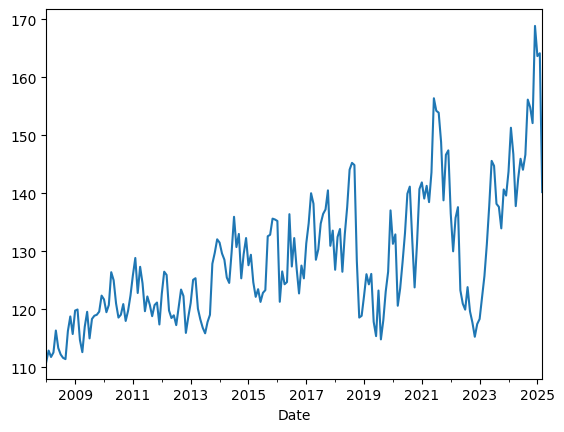

In [ ]:
Volatility_Indicators = pd.read_csv('Indicator - Volatility.csv', parse_dates = True, index_col = [0])
Aug_DF_Test = Volatility_Indicators.apply(lambda col : ADF_test(col)).round(2)
Aug_DF_Test.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Aug_DF_Test.T

In [719]:
Economic_Indicators = pd.read_csv('Indicator - Economic.csv', parse_dates = True, index_col = [0])
Aug_DF_Test = Economic_Indicators.apply(lambda col : ADF_test(col)).round(2)
Aug_DF_Test.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Aug_DF_Test.T

,T-stat,p-value,1%,5%,10%
value,-7.20,0.00,-3.46,-2.88,-2.57
Unemployment Rate,-2.48,0.12,-3.46,-2.88,-2.57
Inflation Rate,-4.07,0.00,-3.46,-2.88,-2.57
Number of Car Sales,-7.64,0.00,-3.46,-2.88,-2.57
Electricity Price CPI in US Cities,-3.59,0.01,-3.46,-2.88,-2.57


In [722]:
Sentiment_Indicators = pd.read_csv('Indicator - Sentiment.csv', parse_dates = True, index_col = [0])
Aug_DF_Test = Sentiment_Indicators.apply(lambda col : ADF_test(col)).round(2)
Aug_DF_Test.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Aug_DF_Test.T

,T-stat,p-value,1%,5%,10%
Overall NFCI,-2.92,0.04,-3.46,-2.88,-2.57
Leverage,-2.94,0.04,-3.46,-2.88,-2.57
Risk,-2.77,0.06,-3.46,-2.88,-2.57
Credit,-4.24,0.00,-3.46,-2.88,-2.57
UMich,-8.72,0.00,-3.46,-2.88,-2.57
BKK Leading Index,-3.77,0.00,-3.46,-2.88,-2.57
CFNAI,-8.99,0.00,-3.46,-2.88,-2.57
St Louis Stress Index,-3.70,0.00,-3.46,-2.88,-2.57
China EPU,-2.11,0.24,-3.46,-2.88,-2.57
US EPU,-2.86,0.05,-3.46,-2.88,-2.57


### S&P Industrials, NASDAQ, EuroStoxx Financial Services and Real Estate Sector Indices

In [686]:
# Returns of the Index
Financial_Index = pd.read_csv('Eurostoxx_Financial_Index.csv', index_col = [0], parse_dates = True)
RealEstate_Index = pd.read_csv('Eurostoxx_Real_Estate_Index.csv', index_col = [0], parse_dates = True)

Financial_Index = np.log(Financial_Index / Financial_Index.shift()).dropna() * 100
RealEstate_Index = np.log(RealEstate_Index / RealEstate_Index.shift()).dropna() * 100



#Fix NASDAQ and Industrials
NASDAQ_Industrials = pd.read_csv('nasdaq_us_industrial_index_rets.csv')
temp = NASDAQ_Industrials.drop(columns = ['gvkeyx']).pivot(
    index = 'datadate',
    values = 'prccd',
    columns = 'tic').copy()
NASDAQ = pd.DataFrame(temp['I0028'].copy())
SP_Industrials = pd.DataFrame(temp['IND.I'].copy())
NASDAQ.index.name = 'Date'
NASDAQ.columns = ['NASDAQ']
SP_Industrials.index.name = 'Date'
SP_Industrials.columns = ['SP Industrials']

NASDAQ = np.log(NASDAQ / NASDAQ.shift()).dropna() * 100
SP_Industrials = np.log(SP_Industrials/SP_Industrials.shift()).dropna() * 100

NASDAQ.to_csv('Returns - Index - NASDAQ.csv')
SP_Industrials.to_csv('Returns - Index - SP_Industrials.csv')
Financial_Index.to_csv('Returns - Index - Financials.csv')
RealEstate_Index.to_csv('Returns - Index - RealEstate.csv')


In [8]:
Industrial_Ratios = pd.read_csv('Industrial_Ratios.csv', parse_dates = True)
Industrial_Ratios.drop(columns = ['adate', 'permno', 'qdate'], inplace = True)
Industrial_Ratios.pivot(index = 'public_date', 
                        columns = ['TICKER'],
                        values = ['pe_op_basic', 'pe_exi', 'roa', 'rd_sale'])

pe_op_basic                          pe_exi                  \
TICKER              DAL      PH     RSG     UAL     DAL      PH     RSG   
public_date                                                               
2018-01-31       11.681  23.152  28.787  10.276  11.729  25.889  29.153   
2018-02-28       10.405  19.088  27.760   9.999  10.889  27.842  17.820   
2018-03-31       10.581  18.292  27.368  10.246  11.073  26.682  17.568   
2018-04-30       10.081  17.606  26.727   9.962  10.549  25.682  17.156   
2018-05-31       11.574  17.005  25.835   9.885  12.173  23.189  17.028   
...                 ...     ...     ...     ...     ...     ...     ...   
2024-07-31        5.452  25.824  33.331   4.289   5.530  26.395  34.091   
2024-08-31        6.001  26.843  34.472   4.720   6.105  27.482  34.876   
2024-09-30        7.174  28.257  33.252   6.116   7.297  28.929  33.642   
2024-10-31        8.082  28.357  32.781   8.388   8.221  29.033  33.166   
2024-11-30        8.475  30.978  34.541  10.892   8.864  31.748  34.928   

                       roa                      rd_sale                   
TICKER          UAL    DAL     PH    RSG    UAL     DAL     PH  RSG  UAL  
public_date                                                               
2018-01-31   10.680  0.154  0.147  0.133  0.149     0.0  0.027  0.0  0.0  
2018-02-28    9.657  0.160  0.150  0.133  0.141     0.0  0.025  0.0  0.0  
2018-03-31    9.896  0.160  0.150  0.133  0.141     0.0  0.025  0.0  0.0  
2018-04-30    9.621  0.160  0.150  0.133  0.141     0.0  0.025  0.0  0.0  
2018-05-31    9.520  0.155  0.152  0.135  0.141     0.0  0.024  0.0  0.0  
...             ...    ...    ...    ...    ...     ...    ...  ...  ...  
2024-07-31    5.614  0.120  0.157  0.152  0.111     0.0  0.017  0.0  0.0  
2024-08-31    4.988  0.117  0.163  0.154  0.106     0.0  0.015  0.0  0.0  
2024-09-30    6.462  0.117  0.163  0.154  0.106     0.0  0.015  0.0  0.0  
2024-10-31    8.863  0.117  0.163  0.154  0.106     0.0  0.015  0.0  0.0  
2024-11-30   11.666  0.109  0.166  0.156  0.104     0.0  0.015  0.0  0.0  

[83 rows x 16 columns]

In [808]:
def split_and_select(df, date_col='Date'):
    """
    Splits a wide DataFrame by ticker (first data row), computes ROA,
    and retains only CapEx/Sales, Operating Leverage, and Return on Assets.
   
    Returns
    -------
    dict[str, pd.DataFrame]
      Mapping ticker → DataFrame with:
        * index = date_col
        * columns = ['CapEx / Sales', 'Operating Leverage', 'Return on Assets']
    """
    ticker_row = df.iloc[0]
    unique_tks = pd.unique(ticker_row.dropna())

    out = {}
    for tk in unique_tks:
        # 2) Pick columns for this ticker + date
        cols = [c for c, t in zip(df.columns, ticker_row) if t == tk]
        if date_col in df.columns:
            cols = [date_col] + cols

        sub = df[cols].iloc[1:].copy()

        # 3) Rename to drop .1/.2 suffixes
        rename_map = {c: c.split('.')[0] for c in cols if c != date_col}
        sub.rename(columns=rename_map, inplace=True)

        # 4) Coerce to numeric
        #    any non-convertible → NaN
        for numcol in ('Net Income', 'Assets'):
            if numcol in sub.columns:
                sub[numcol] = pd.to_numeric(sub[numcol], errors='coerce')

        # 5) Compute ROA = Net Income / Assets
        sub['Return on Assets'] = sub['Net Income'] / sub['Assets']

        # 6) Keep only the three target columns
        keep = ['CapEx / Sales', 'Operating Leverage (DOL)', 'Return on Assets']
        # Make sure Date is index
        if date_col in sub.columns:
            # try to parse as datetime if not already
            sub[date_col] = pd.to_datetime(sub[date_col], errors='coerce')
            sub.set_index(date_col, inplace=True)

        out[tk] = sub[keep].copy()

    return out

## Compiling and Processing of Broad-Indices and Sector-Indices Returns Data (Section X.X)

In [753]:
US_Indices_Returns = pd.read_csv('Returns - Index - Major US Indices.csv', index_col = [0], parse_dates = True)
Sector_Indices_Returns = pd.read_csv('Returns - Index - US Sectors.csv', index_col = [0], parse_dates = True)
# Refine window of insample testing 
US_Indices_Returns = US_Indices_Returns.loc['2009-12':'2025-03-01']
Sector_Indices_Returns= Sector_Indices_Returns.loc['2009-12':'2025-03-01']
US_Indices_Returns.to_csv('Returns - Index - Major US Indices 2010-2025.csv')
Sector_Indices_Returns.to_csv('Returns - Index - US Sector Indices 2010-2025.csv')

# Use average squared returns as realized vol
Squared_Rets = US_Indices_Returns.loc[:, ['.DJI', '.IXIC', '.INX', '.NDX', '.SPX', '.SPSUPX', '.GSPTSE']] ** 2
Squared_Rets.index = Squared_Rets.index.to_period('D')
Squared_Rets = Squared_Rets.resample('M').mean()
Squared_Rets.loc['2010':].to_csv('Realized Volatility - Major US Indices.csv')

Sector_Squared_Rets  = Sector_Indices_Returns.loc[:, ['.OEX', '.5SP25', '.5SP40', '.5SP35', '.5SP55', '.5SP60', '.5SP15','.TRCCRBTR', '.MID', '.SPCY', '.SPCDNX']] ** 2
Sector_Squared_Rets.index = Sector_Squared_Rets.index.to_period('D')
Sector_Squared_Rets = Sector_Squared_Rets.resample('M').mean()
Sector_Squared_Rets.loc['2010':].to_csv('Realized Volatility - Sector Indices.csv')

C:\Users\Phillip\AppData\Local\Temp\ipykernel_30332\236366705.py:12: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  Squared_Rets = Squared_Rets.resample('M').mean()
C:\Users\Phillip\AppData\Local\Temp\ipykernel_30332\236366705.py:17: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  Sector_Squared_Rets = Sector_Squared_Rets.resample('M').mean()
